# Day 29: Data Cleaning – Deep Dive with Titanic Dataset

## Objective
In this session, we move from **EDA to action**.

By the end of this session, students will be able to:
- Identify data quality issues using EDA
- Take logical data cleaning decisions
- Handle missing values, duplicates, and outliers
- Standardize categorical variables
- Understand insights behind every data visualization
- Validate the dataset after cleaning


## 1. Import Required Libraries

In [10]:
import  numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

## 2. Load the Dataset


In [12]:
df = pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 3. Initial Dataset Health Check
Let us understand the structure and basic statistics of the dataset.


In [8]:
df.shape

(891, 12)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Missing Value Analysis
We identify missing values and calculate their percentage to make informed decisions.

In [26]:
missing_count = df.isnull().sum()

missing_percent = (missing_count / len(df))* 100

pd.DataFrame({
    "Missing_count": missing_count,
    "Missing_percentage":missing_percent
}).sort_values(by = "Missing_percentage",ascending = False)

,Missing_count,Missing_percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


### Cleaning Strategy (Decision-Based)

- **Age** → Numerical column, slightly skewed → Fill with median  
- **Embarked** → Categorical column with very few missing → Fill with mode  
- **Cabin** → Very high missing percentage → Drop the column

In [32]:

df["Age"].fillna(df["Age"].median(), inplace = True)

In [36]:
df["Embarked"].fillna(df["Embarked"].mode, inplace = True)
df.drop(columns = ["Cabin"],inplace = True)

In [38]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 5. Handling Duplicate Records
Duplicates can lead to biased analysis and incorrect model learning.


In [40]:
df.duplicated().sum()

0

## 6. Cleaning Categorical Data
We standardize text data to avoid category mismatch.

In [42]:
df["Sex"] = df["Sex"].str.lower()
df["Embarked"] = df["Embarked"].str.strip()

In [44]:
df["Sex"]

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: object

In [50]:
df["Embarked"]

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

## 7. Outlier Detection – Fare Column
We use a boxplot to visually identify outliers.

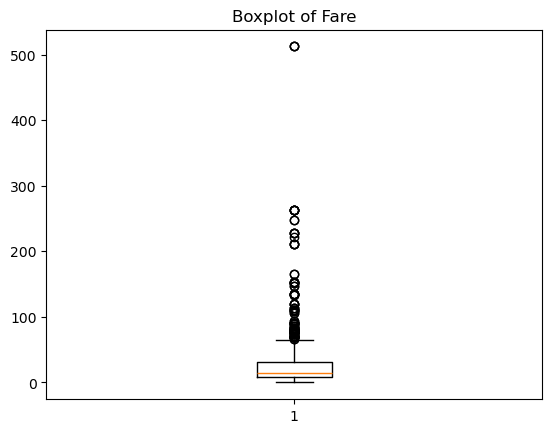

In [58]:
plt.boxplot(df["Fare"])
plt.title("Boxplot of Fare")
plt.show()

### Insights:
- Fare is **right-skewed**, indicating some passengers paid very high prices
- Several extreme values are present beyond the upper whisker
- These outliers can significantly affect mean and variance
- Outliers may represent premium cabins and should not be blindly removed

## 8. Treating Outliers Using IQR Method (Capping)
Instead of removing outliers, we cap them to preserve data size.

In [60]:
# lower ----> iqr -----> q3 /q1------> 75 & 25th percent value 

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3- Q1

lower_whisker = Q1 - 1.5* IQR
upper_whisker = Q3 + 1.5* IQR

In [77]:
df["Fare"] = np.where(df["Fare"] > upper_whisker ,upper_whisker , df["Fare"])
df["Fare"] = np.where(df["Fare"] < lower_whisker , lower_whisker , df["Fare"])



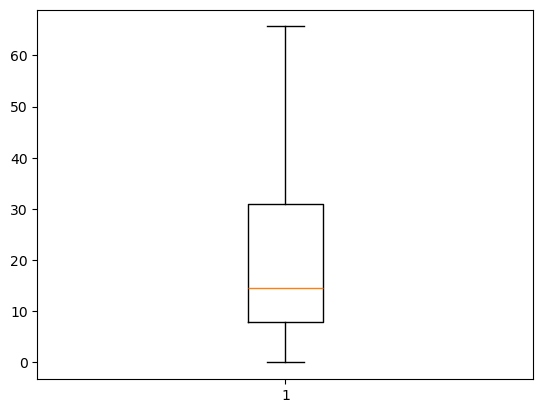

In [87]:
plt.boxplot(df["Fare"])
plt.show()

### After capping and adjusting the outliers 

## 9. Feature Engineering – Extracting Title from Name

Passenger titles like Mr, Mrs, Miss can give meaningful social and age-related information.

In [89]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


### Insights:
- Titles help identify gender and approximate age groups
- Certain titles appear rarely and may need grouping later
- Feature engineering can improve model performance significantly

## 10. Dropping Irrelevant Columns
These columns do not add predictive or analytical value.

In [42]:
# df.head()
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

KeyError: 'Embarked'

In [43]:
df

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",Male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",Male,26.0,0,0,111369,30.0000,C148,C


## 11. Standardizing Column Names
We convert column names to lowercase for consistency.

In [41]:
df.rename(columns = lambda x :x.lower(),inplace = True)

## 12. Final Dataset Validation
We confirm that all cleaning steps were successful.

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   <built-in method lower of str object at 0x000001BC6C669DF0>  891 non-null    int64  
 1   <built-in method lower of str object at 0x000001BC6C646580>  891 non-null    int64  
 2   <built-in method lower of str object at 0x000001BC6C6465E0>  891 non-null    object 
 3   <built-in method lower of str object at 0x000001BC6C646610>  891 non-null    float64
 4   <built-in method lower of str object at 0x000001BC6C646640>  891 non-null    int64  
 5   <built-in method lower of str object at 0x000001BC6C646670>  891 non-null    int64  
 6   <built-in method lower of str object at 0x000001BC6C6466D0>  891 non-null    float64
 7   <built-in method lower of str object at 0x000001BC6C4D3C30>  889 non-null    obje

In [107]:
df.isnull().sum()

<built-in method lower of str object at 0x000001BC6C669DF0>    0
<built-in method lower of str object at 0x000001BC6C646580>    0
<built-in method lower of str object at 0x000001BC6C6465E0>    0
<built-in method lower of str object at 0x000001BC6C646610>    0
<built-in method lower of str object at 0x000001BC6C646640>    0
<built-in method lower of str object at 0x000001BC6C646670>    0
<built-in method lower of str object at 0x000001BC6C6466D0>    0
<built-in method lower of str object at 0x000001BC6C4D3C30>    2
dtype: int64

## 13. Key Takeaways
- EDA helps identify data problems
- Data cleaning requires logical decisions, not blind operations
- Outliers and missing values must be handled carefully
- Always validate data after cleaning

### Assignment
- Perform EDA again on the cleaned dataset
- Compare plots before and after cleaning
- Document at least 5 insights from the cleaned data


## FEW EXTRA ANALYSIS PROBLEM STATEMENT

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


## Which columns have the most missing values?

In [15]:
import pandas as pd

df = pd.read_csv("titanic.csv")
df

In [8]:

missing_values = df.isnull().sum()


missing_values_sorted = missing_values.sort_values(ascending=False)

print(missing_values_sorted)

Cabin          327
Age             86
Fare             1
PassengerId      0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Embarked         0
dtype: int64


## How many duplicate rows exist?

In [16]:
duplicate_rows = df.duplicated().sum()
print(duplicate_rows)

0


## Convert “male”, “Male”, “M” → “Male”

In [18]:
df['Sex'] = df['Sex'].replace(['male', 'Male', 'M'], 'Male')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",Male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",Male,26.0,0,0,111369,30.0000,C148,C


## Clean spaces in string columns

In [20]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,NaN,S


## Convert AGE column to numeric INT

In [24]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",Male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",Male,26.0,0,0,111369,30.0000,C148,C


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Find invalid or suspicious values

In [26]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.duplicated().sum()

np.int64(0)

In [30]:
df[df['Age'] < 0]
df[df['Age'] > 100]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [31]:
df['Sex'].unique()
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [32]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


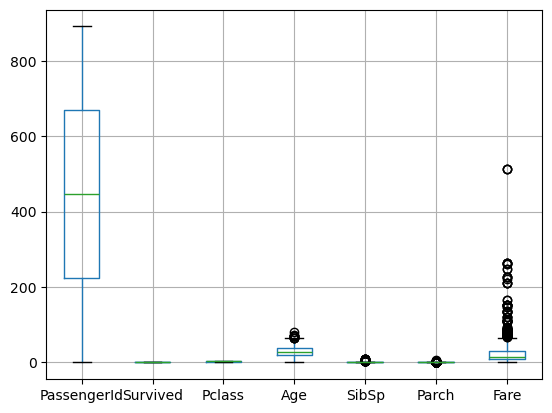

In [33]:
import matplotlib.pyplot as plt

df.boxplot()
plt.show()

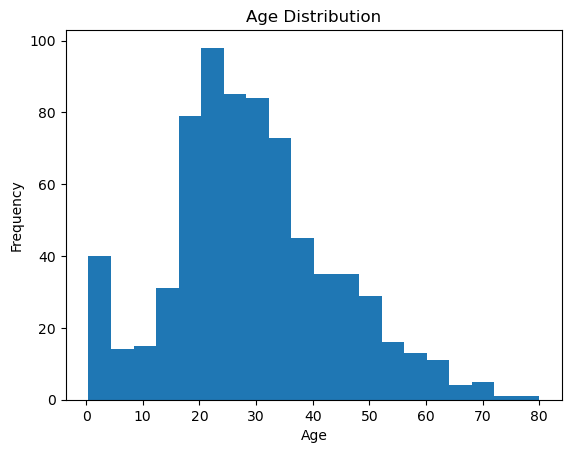

In [35]:
import matplotlib.pyplot as plt

df['Age'].plot(kind='hist', bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

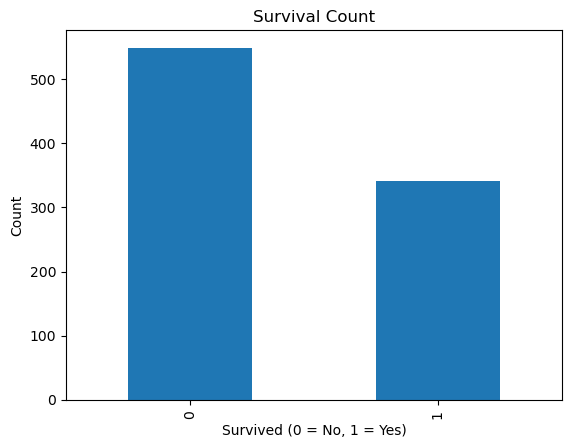

In [36]:
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

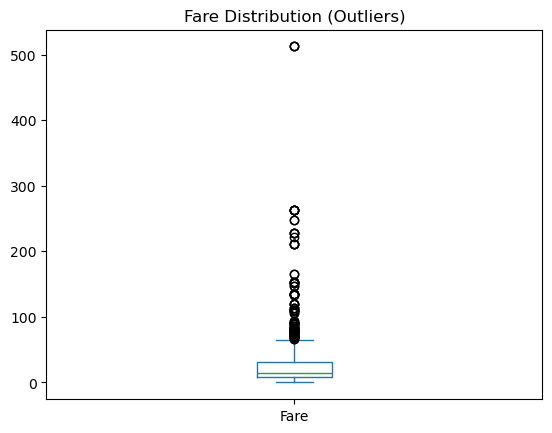

In [37]:
df['Fare'].plot(kind='box')
plt.title("Fare Distribution (Outliers)")
plt.show()